# Import Libaries

In [2]:
# Data manipulation and OS interaction
import numpy as np  # Numerical operations
import pandas as pd  # Data handling
import os  # Operating system interactions

# Visualization
import matplotlib.pyplot as plt  # Plotting graphs
import seaborn as sns
from sklearn.metrics import (
    classification_report,  # Precision, recall, f1-score
    roc_auc_score,          # AUC for ROC
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay  # Display confusion matrix
)

# Machine learning models and tuning
from sklearn.ensemble import RandomForestClassifier  # Random Forest model
from xgboost import XGBClassifier  # XGBoost classifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV  # Splitting & tuning

# NLP & deep learning (for ClinicalBERT embeddings later)
import torch
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm  # Progress bar

# Handling class imbalance
from imblearn.over_sampling import SMOTE  # Synthetic Minority Over-sampling Technique

# Structured Data

In [3]:
#Load Data from Local MIMIC-IV Datasets
patients_path = "S:/Downloads/mimic-iv-2.2/mimic-iv-2.2/hosp/patients.csv.gz" #Patient demographic Info
icustays_path = "S:/Downloads/mimic-iv-2.2/mimic-iv-2.2/icu/icustays.csv.gz" #ICU admission and discharge record
diagnoses_path = "S:/Downloads/mimic-iv-2.2/mimic-iv-2.2/hosp/diagnoses_icd.csv.gz" #ICD diagnosis code


#Load patient and ICU stay data
df_patients = pd.read_csv(patients_path)
df_icustays = pd.read_csv(icustays_path)

#Load and Filter Diagnoses in Chunks (to avoid memory issues)
diagnosis_chunks = [] #Temporary list to hold filtered chunks
target_subject_ids = set(df_patients['subject_id'].unique())  #Keep only relevant patient 

#Process diagnoses.csv in chunks of 50,000 rows
for chunk in pd.read_csv(diagnoses_path, chunksize=50000): 
    filtered_chunk = chunk[chunk['subject_id'].isin(target_subject_ids)]
    diagnosis_chunks.append(filtered_chunk)  #Append each filtered chunk

#Combine all chunks into one DataFrame
df_diagnoses = pd.concat(diagnosis_chunks, ignore_index=True)


In [4]:
# Convert ICU times to datetime
df_icustays['intime'] = pd.to_datetime(df_icustays['intime'])
df_icustays['outtime'] = pd.to_datetime(df_icustays['outtime'])

# Sort ICU stays by subject and admission time
df_icustays = df_icustays.sort_values(by=['subject_id', 'intime']).reset_index(drop=True)

## Readmission Labels

In [5]:
# Add Readmission Labels (within 30 days) 
readmission_labels = [] 
"""Empty list to hold readmission data 
   0 = Not Readmitted
   1= Readmitted to ICU within 30 days
"""
# Loop through ICU stays grouped by patient
for subject_id, stays in df_icustays.groupby('subject_id'): #A datafram that has patient ICU stays
    stays = stays.sort_values(by='intime').reset_index(drop=True) 
    readmitted = [0] * len(stays) #List of 0 and 1 for ICU readmissionc
    for i in range(len(stays) - 1):
        delta = (stays.loc[i + 1, 'intime'] - stays.loc[i, 'outtime']).days #Calculates number of days between discharge and the next admission
        if 0 < delta <= 30: #If patient was not readmitted to the ICU in 30 Days
            readmitted[i] = 1 #If reamitted 1
    readmission_labels.extend(readmitted) #Adds readmitted data to list

df_icustays = df_icustays.iloc[:len(readmission_labels)] #Data frame only has as many rows as labels
df_icustays['readmitted'] = readmission_labels #Adds reamitted colum to ICU stays data set

## Merge and Engineer Structured Features

In [6]:
#Merge demographic information from df_patients into df_icustays
df_merged = df_icustays.merge(df_patients[['subject_id', 'gender', 'anchor_age']], on='subject_id', how='left')

#Counts how many diagnosis codes for each hospital admission
diagnosis_counts = df_diagnoses.groupby('hadm_id').size().reset_index(name='diagnosis_count')
df_merged = df_merged.merge(diagnosis_counts, on='hadm_id', how='left')
df_merged['diagnosis_count'] = df_merged['diagnosis_count'].fillna(0) #Fills missing values with 0 

#Convert gender to a binary value
df_merged['gender'] = df_merged['gender'].map({'M': 0, 'F': 1})

#Add length of stay and number of prior stays
df_merged['length_of_stay'] = (df_merged['outtime'] - df_merged['intime']).dt.total_seconds() / (60*60*24)

# Count number of prior ICU stays per patient
df_merged['prior_stays'] = df_merged.groupby('subject_id').cumcount()

#Save structured data as pickle 
df_merged.to_pickle("structured_data.pkl")  



In [7]:
#Prepare Data for Model
X = df_merged[['anchor_age', 'gender', 'length_of_stay', 'prior_stays', 'diagnosis_count']]
y = df_merged['readmitted'] #Target vector

# Train-test split, 80% Training & 20% Test, #Random state to ensure reproducibility 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

## Functions

####        Confusion Matrix Funtcion

In [8]:
def plot_confusion_matrix_with_labels(model, X_test, y_test, class_names, model_name="Model", cmap="viridis", filename=None):
    """
    Plots a labeled confusion matrix with both counts and row-based percentages.
    
    Parameters:
    - model: Trained classifier
    - X_test: Test feature set
    - y_test: True labels
    - class_names: List of class labels, e.g. ["No", "Yes"]
    - model_name: Title for the plot
    - cmap: Matplotlib colormap name
    - filename: If provided, saves the image to this path
    """
    from sklearn.metrics import confusion_matrix, classification_report
    import seaborn as sns
    import matplotlib.pyplot as plt
    import numpy as np

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Combine count and percentage
    annot = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            count = cm[i, j]
            percent = cm_percent[i, j]
            annot[i, j] = f"{count}\n({percent:.1%})"

    # Plot
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_percent, annot=annot, fmt='', cmap=cmap,
                xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title(f'Confusion Matrix: {model_name}')
    
    if filename:
        plt.savefig(filename, bbox_inches='tight')
    
    plt.show()

    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_test, y_pred, zero_division=0))


#### ROC Function

In [9]:
def plot_roc_curve(model, X_test, y_test, model_name="Model"):
    """
    Plots ROC Curve and prints AUC for any classifier model with predict_proba.
    """
    try:
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_score = roc_auc_score(y_test, y_prob)

        plt.figure()
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.2f})')
        plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {model_name}')
        plt.legend(loc='lower right')
        plt.grid(True)
        plt.show()

        print(f"{model_name} AUC-ROC Score: {auc_score:.4f}")
        return auc_score

    except Exception as e:
        print(f"{model_name} ROC Error:", e)

## Random Forest Pre SMOTE

Class distribution in y_train (Before SMOTE):
readmitted
0    52125
1     6419
Name: count, dtype: int64


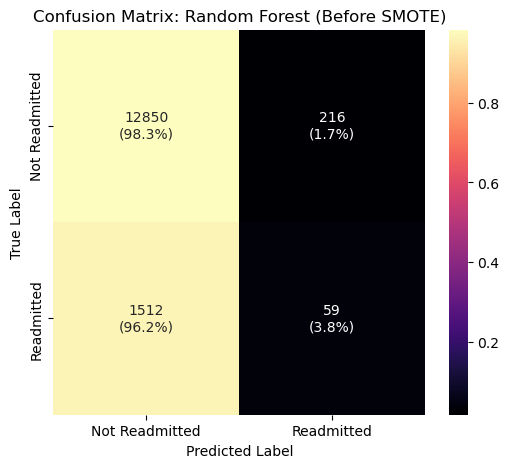


Classification Report for Random Forest (Before SMOTE):
              precision    recall  f1-score   support

           0       0.89      0.98      0.94     13066
           1       0.21      0.04      0.06      1571

    accuracy                           0.88     14637
   macro avg       0.55      0.51      0.50     14637
weighted avg       0.82      0.88      0.84     14637



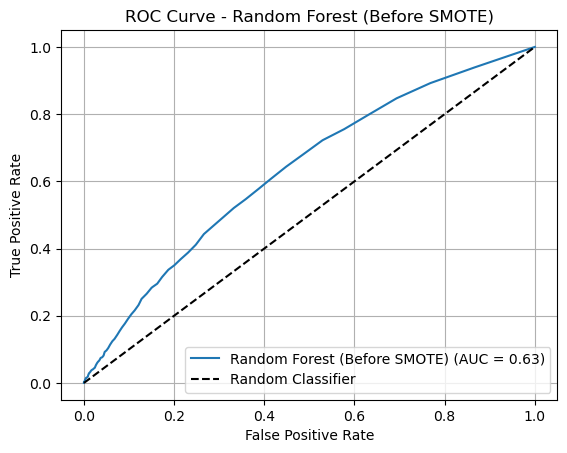

Random Forest (Before SMOTE) AUC-ROC Score: 0.6313


0.6312943063483312

In [10]:
#Train Random Forest on Structured Data (Before SMOTE) 
rf_before = RandomForestClassifier(random_state=42)
rf_before.fit(X_train, y_train)

print("Class distribution in y_train (Before SMOTE):")
print(y_train.value_counts())


#Confusion Matrix 
class_names = ["Not Readmitted", "Readmitted"]
plot_confusion_matrix_with_labels(
    model=rf_before,
    X_test=X_test,
    y_test=y_test,
    class_names=class_names,
    model_name= "Random Forest (Before SMOTE)",
    cmap="magma"
)

#ROC
plot_roc_curve(rf_before, X_test, y_test, model_name="Random Forest (Before SMOTE)")

## SMOTE

In [11]:
#Apply SMOTE to Balance Classes
smote = SMOTE(random_state=42)


# Apply SMOTE only on training data to prevent data leakage
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

## Random Forest with SMOTE

In [12]:
#Train Model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_resampled, y_resampled)

RandomForestClassifier(random_state=42)

Class Distribution- Random Forest:
readmitted
0    52125
1    52125
Name: count, dtype: int64


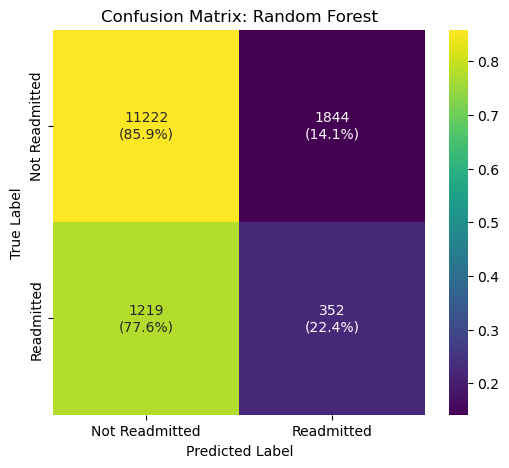


Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88     13066
           1       0.16      0.22      0.19      1571

    accuracy                           0.79     14637
   macro avg       0.53      0.54      0.53     14637
weighted avg       0.82      0.79      0.81     14637



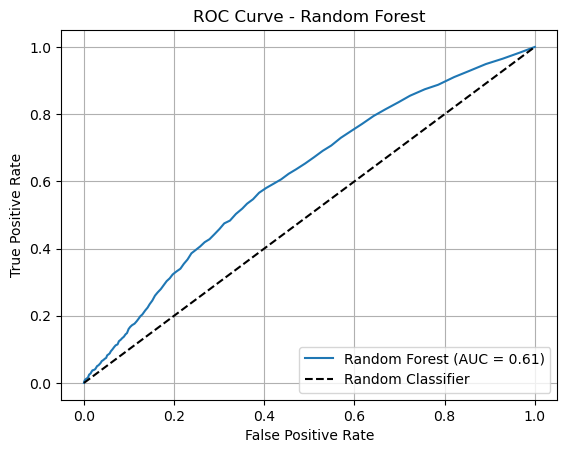

Random Forest AUC-ROC Score: 0.6132


0.6131706063024494

In [13]:
#Make Predictions on the Test Set

# Predict binary class labels (0 = not readmitted, 1 = readmitted)
y_pred = rf_model.predict(X_test)
# Predict probabilities for class 1 (readmitted); used for ROC/AUC
y_prob = rf_model.predict_proba(X_test)[:, 1] 

# Evaluate Model Performance
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Confirm that the data was balanced
print("Class Distribution- Random Forest:")
print(pd.Series(y_resampled).value_counts())

#Confusion Matrix
plot_confusion_matrix_with_labels(
    rf_model, X_test, y_test,
    class_names=["Not Readmitted", "Readmitted"],
    model_name="Random Forest",
    cmap="viridis"
)

#ROC Curve
plot_roc_curve(rf_model, X_test, y_test, model_name="Random Forest")


## XGBoost

Class Distribution After SMOTE (Training Set):
readmitted
0    52125
1    52125
Name: count, dtype: int64


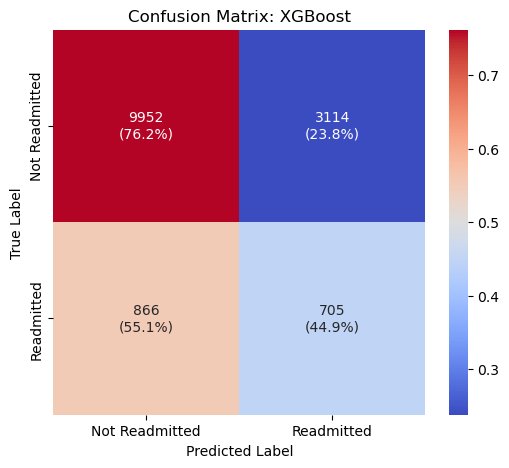


Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.92      0.76      0.83     13066
           1       0.18      0.45      0.26      1571

    accuracy                           0.73     14637
   macro avg       0.55      0.61      0.55     14637
weighted avg       0.84      0.73      0.77     14637



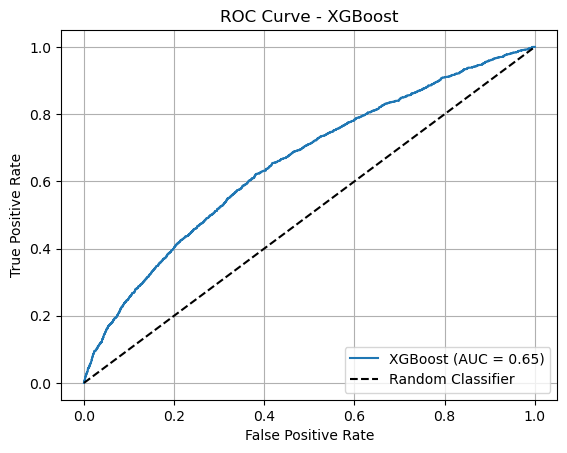

XGBoost AUC-ROC Score: 0.6547


0.6546733603271371

In [14]:
#Apply SMOTE to Balance the Training Set
smote = SMOTE(random_state=42)

# Apply SMOTE only on training data to prevent data leakage
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Print class distribution to confirm balance
print("Class Distribution After SMOTE (Training Set):")
print(y_train_resampled.value_counts())

# Initialize XGBoost Classifier with recommended settings
xgb_model = XGBClassifier(
    n_estimators=100,       # Number of boosting rounds (trees)
    learning_rate=0.1,      # Step size shrinkage
    max_depth=5,            # Tree depth (controls complexity)
    subsample=0.8,          # % of rows used per tree (adds regularization)
    colsample_bytree=0.8,   # % of features used per tree
    eval_metric='logloss',  # Loss function for binary classification
    random_state=42         # Ensures consistent results
)

# Train on SMOTE-balanced training data
xgb_model.fit(X_train_resampled, y_train_resampled)

# Predict on test set
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]


# Confusion Matrix
plot_confusion_matrix_with_labels(
    xgb_model, X_test, y_test,
    class_names=["Not Readmitted", "Readmitted"],
    model_name="XGBoost",
    cmap="coolwarm"
)

# ROC
plot_roc_curve(xgb_model, X_test, y_test, model_name="XGBoost")


Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 1.0}


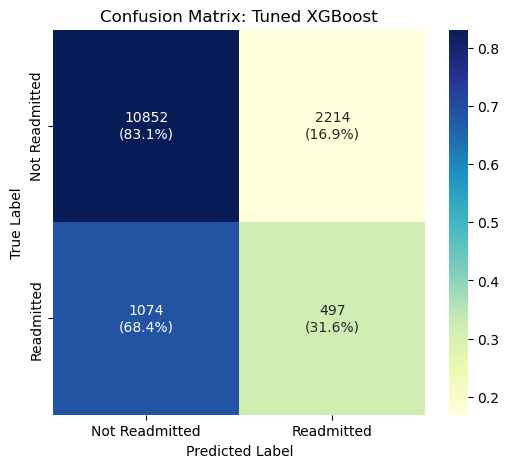


Classification Report for Tuned XGBoost:
              precision    recall  f1-score   support

           0       0.91      0.83      0.87     13066
           1       0.18      0.32      0.23      1571

    accuracy                           0.78     14637
   macro avg       0.55      0.57      0.55     14637
weighted avg       0.83      0.78      0.80     14637



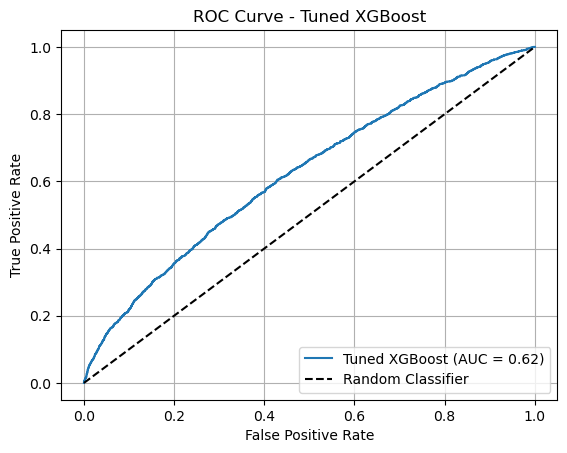

Tuned XGBoost AUC-ROC Score: 0.6225


0.622520727408214

In [15]:
# Define parameter grid
param_dist = {
    'n_estimators': [100, 200, 300],         # Number of boosting rounds (trees)
    'learning_rate': [0.01, 0.05, 0.1, 0.2], # Step size shrinkage to control overfitting
    'max_depth': [3, 5, 7, 10],              # Tree depth; deeper trees capture more complexity
    'subsample': [0.6, 0.8, 1.0],            # % of rows used per tree
    'colsample_bytree': [0.6, 0.8, 1.0],     # % of features used per tree
    'gamma': [0, 0.1, 0.3, 0.5]              # Minimum loss reduction required to make a split
}

# Initialize base model
xgb_clf = XGBClassifier(
    eval_metric='logloss',  # Loss function for binary classification
    random_state=42         # For reproducibility
)

#  Set Up RandomizedSearchCV for Hyperparameter Tuning
random_search = RandomizedSearchCV(
    estimator=xgb_clf,                  # Model to be tuned
    param_distributions=param_dist,     # Grid of parameters to search
    scoring='recall',                   # Optimize for recall
    n_iter=25,                          # Number of random combinations to test
    cv=3,                               # 3-fold cross-validation
    verbose=2,                          # Print progress info during tuning
    random_state=42,                    # For reproducibility
    n_jobs=-1                           # Use all processors to speed up the search
)

# Fit the RandomizedSearchCV on SMOTE-balanced Training Data
random_search.fit(X_train_resampled, y_train_resampled)

# Best estimator
best_xgb = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)


# Predict on test set
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

# Confusion Matrix
plot_confusion_matrix_with_labels(
    best_xgb, X_test, y_test,
    class_names=["Not Readmitted", "Readmitted"],
    model_name="Tuned XGBoost",
    cmap="YlGnBu"
)
#ROC
plot_roc_curve(best_xgb, X_test, y_test, model_name="Tuned XGBoost")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Narrowed Parameters: {'subsample': 0.8, 'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 1.0}


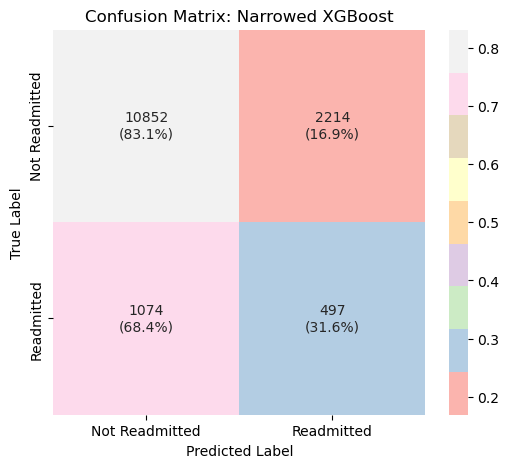


Classification Report for Narrowed XGBoost:
              precision    recall  f1-score   support

           0       0.91      0.83      0.87     13066
           1       0.18      0.32      0.23      1571

    accuracy                           0.78     14637
   macro avg       0.55      0.57      0.55     14637
weighted avg       0.83      0.78      0.80     14637



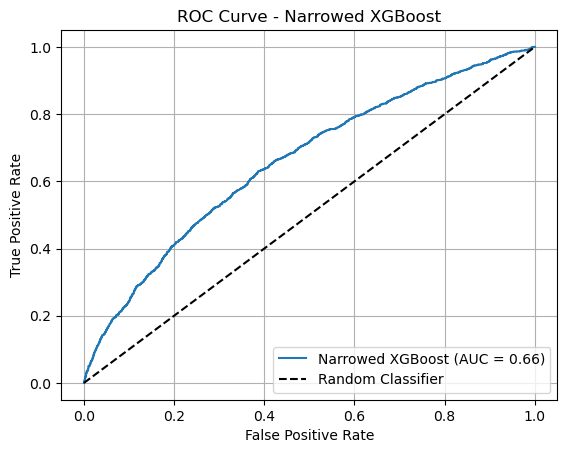

Narrowed XGBoost AUC-ROC Score: 0.6585


0.6585061514557196

In [16]:
# XGBoost Hyperparameter Tuning (Narrowed for High Recall)

# Narrowed parameter grid focused on recall

# This grid defines a focused range of hyperparameters
# The goal is to tune the model for high recall
param_dist_narrow = {
    'n_estimators': [150, 200, 250],         # Number of boosting rounds (trees)
    'learning_rate': [0.05, 0.1],            # Learning rate 
    'max_depth': [3, 4, 5],                  # Depth of trees
    'subsample': [0.8, 1.0],                 # % of rows used per tree (for randomness and regularization)
    'colsample_bytree': [0.8, 1.0],          # % of features used per tree
    'gamma': [0, 0.1]                        # Minimum loss reduction to make a split (adds regularization)
}

xgb_clf_narrow = XGBClassifier(
    eval_metric='logloss',  # Binary classification loss
    random_state=42         # For reproducibility
)

# Perform Randomized Hyperparameter Search

random_search_narrow = RandomizedSearchCV(
    estimator=xgb_clf_narrow,
    param_distributions=param_dist_narrow,
    scoring='recall',      # Prioritize recall during tuning
    n_iter=20,             # Number of random combinations to try
    cv=3,                  # 3-fold cross-validation
    verbose=2,             # Display progress
    random_state=42,       # Reproducibility
    n_jobs=-1              # Use all CPU cores for speed
)

# Fit the search on the SMOTE-balanced training data
random_search_narrow.fit(X_train_resampled, y_train_resampled)

# Extract the best-performing model from the tuning process
best_xgb_narrow = random_search_narrow.best_estimator_

# Display the best combination of parameters discovered
print("Best Narrowed Parameters:", random_search_narrow.best_params_)

# Predictions
y_pred_xgb_narrow = best_xgb_narrow.predict(X_test)
y_prob_xgb_narrow = best_xgb_narrow.predict_proba(X_test)[:, 1]


# Confusion Matrix
plot_confusion_matrix_with_labels(
    best_xgb, X_test, y_test,
    class_names=["Not Readmitted", "Readmitted"],
    model_name="Narrowed XGBoost",
    cmap="Pastel1"
)

#ROC
plot_roc_curve(best_xgb_narrow, X_test, y_test, model_name="Narrowed XGBoost")

# Unstructed Data

In [17]:
#Load the compressed discharge notes file
df_raw = pd.read_csv(
    r"S:\Downloads\mimic-iv-note-deidentified-free-text-clinical-notes-2.2\note\discharge.csv.gz",
    compression='gzip'
)

# Preview the data 
print("Raw rows loaded:", len(df_raw))
print("Unique note types:", df_raw['note_type'].unique())
print(df_raw.head())

# Filter for Discharge Summaries 
df_notes = df_raw[df_raw['note_type'] == 'DS']

# Keep only necessary columns 
df_notes = df_notes[['hadm_id', 'text']].dropna()
df_notes = df_notes.drop_duplicates(subset='hadm_id')
df_notes = df_notes[df_notes['text'].str.strip() != ""].reset_index(drop=True)

#Check
print("Cleaned discharge summaries:", len(df_notes))
print(df_notes.head())

Raw rows loaded: 331793
Unique note types: ['DS']
          note_id  subject_id   hadm_id note_type  note_seq  \
0  10000032-DS-21    10000032  22595853        DS        21   
1  10000032-DS-22    10000032  22841357        DS        22   
2  10000032-DS-23    10000032  29079034        DS        23   
3  10000032-DS-24    10000032  25742920        DS        24   
4  10000084-DS-17    10000084  23052089        DS        17   

             charttime            storetime  \
0  2180-05-07 00:00:00  2180-05-09 15:26:00   
1  2180-06-27 00:00:00  2180-07-01 10:15:00   
2  2180-07-25 00:00:00  2180-07-25 21:42:00   
3  2180-08-07 00:00:00  2180-08-10 05:43:00   
4  2160-11-25 00:00:00  2160-11-25 15:09:00   

                                                text  
0   \nName:  ___                     Unit No:   _...  
1   \nName:  ___                     Unit No:   _...  
2   \nName:  ___                     Unit No:   _...  
3   \nName:  ___                     Unit No:   _...  
4   \nName:  

# ClinicalBERT

In [18]:
#Load ClinicalBERT model and tokenizer 


# Load ClinicalBERT tokenizer and model from HuggingFace's Transformers library
# This model is pre-trained specifically for biomedical and clinical text
tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
model = AutoModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

# Define embedding function
def embed_text_bert(texts, tokenizer, model, device='cpu', max_length=512):
    embeddings = []
    model.to(device)
    model.eval()

    with torch.no_grad():
        for text in tqdm(texts, desc="Embedding discharge summaries"):
            inputs = tokenizer(
                text,
                return_tensors="pt",
                truncation=True,
                padding="max_length",
                max_length=max_length
            )
            inputs = {key: val.to(device) for key, val in inputs.items()}
            outputs = model(**inputs)
            cls_embedding = outputs.last_hidden_state[:, 0, :]  # Take CLS token
            embeddings.append(cls_embedding.cpu().numpy().squeeze())

    return np.vstack(embeddings)

# Run embeddings on first 2500 notes 
texts = df_notes['text'].iloc[:2500].tolist() # Discharge summaries 
hadm_ids = df_notes['hadm_id'].iloc[:2500].tolist() # Corresponding hospital admission IDs

# Generate BERT Embeddings
bert_array = embed_text_bert(texts, tokenizer, model)

# Create DataFrame for embeddings
df_bert_embeddings = pd.DataFrame(
    bert_array,
    columns=[f"bert_feature_{i}" for i in range(bert_array.shape[1])]
)

# Attach hospital admission ID for merging with other clinical data later
df_bert_embeddings['hadm_id'] = hadm_ids 

# Save embeddings for reuse
df_bert_embeddings.to_pickle("bert_embeddings.pkl")
print("BERT embeddings saved as bert_embeddings.pkl")

# Preview 
print("ClinicalBERT embeddings shape:", df_bert_embeddings.shape)
print(df_bert_embeddings.head())


Embedding discharge summaries: 100%|██████████| 2500/2500 [12:59<00:00,  3.21it/s]


BERT embeddings saved as bert_embeddings.pkl
ClinicalBERT embeddings shape: (2500, 769)
   bert_feature_0  bert_feature_1  bert_feature_2  bert_feature_3  \
0        0.017390        0.199950       -0.519283        0.140157   
1       -0.172971        0.352131       -0.507876        0.345762   
2       -0.062416        0.313833       -0.351321        0.145421   
3        0.087476        0.239996       -0.486023        0.244924   
4       -0.173181        0.255776       -0.353238        0.032470   

   bert_feature_4  bert_feature_5  bert_feature_6  bert_feature_7  \
0       -0.294883       -0.007328        0.223227       -0.028499   
1       -0.267376        0.011552        0.231053        0.074064   
2       -0.020986        0.052596        0.173338        0.143407   
3       -0.136639        0.032577        0.282645        0.089654   
4       -0.061390       -0.102563        0.175804       -0.104470   

   bert_feature_8  bert_feature_9  ...  bert_feature_759  bert_feature_760  \
0   

# Merge Structed and Unstructed

In [19]:
# Load both DataFrames
df_structured = pd.read_pickle("structured_data.pkl")
df_bert_embeddings = pd.read_pickle("bert_embeddings.pkl")

# Merge on hadm_id
final_df = df_structured.merge(df_bert_embeddings, on='hadm_id', how='inner')

print("Final merged shape:", final_df.shape)
print(final_df.head())

Final merged shape: (524, 782)
   subject_id   hadm_id   stay_id  \
0    10000032  29079034  39553978   
1    10000980  26913865  39765666   
2    10001217  24597018  37067082   
3    10001217  27703517  34592300   
4    10001725  25563031  31205490   

                                     first_careunit  \
0                Medical Intensive Care Unit (MICU)   
1                Medical Intensive Care Unit (MICU)   
2               Surgical Intensive Care Unit (SICU)   
3               Surgical Intensive Care Unit (SICU)   
4  Medical/Surgical Intensive Care Unit (MICU/SICU)   

                                      last_careunit              intime  \
0                Medical Intensive Care Unit (MICU) 2180-07-23 14:00:00   
1                Medical Intensive Care Unit (MICU) 2189-06-27 08:42:00   
2               Surgical Intensive Care Unit (SICU) 2157-11-20 19:18:02   
3               Surgical Intensive Care Unit (SICU) 2157-12-19 15:42:24   
4  Medical/Surgical Intensive Care Unit 

## Random Forest with Structed and Unstructed Data before SMOTE

Class distribution in full dataset:
readmitted
0    469
1     55
Name: count, dtype: int64
Class distribution in test set:
readmitted
0    91
1    14
Name: count, dtype: int64


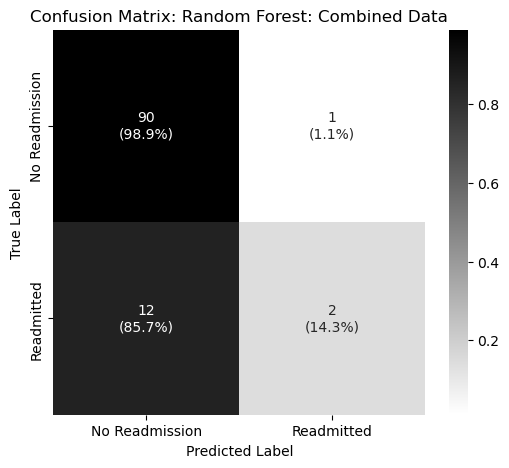


Classification Report for Random Forest: Combined Data:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93        91
           1       0.67      0.14      0.24        14

    accuracy                           0.88       105
   macro avg       0.77      0.57      0.58       105
weighted avg       0.85      0.88      0.84       105



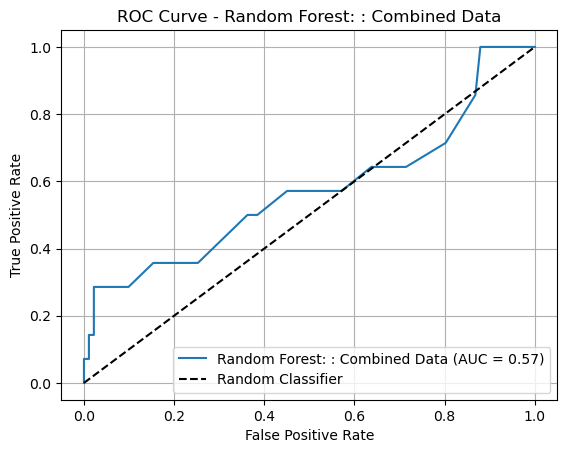

Random Forest: : Combined Data AUC-ROC Score: 0.5718


0.5718210361067504

In [20]:
# Prepare Features and Labels

# Drop ID and non-numeric columns
X = final_df.drop(columns=['readmitted', 'hadm_id', 'subject_id', 'stay_id', 'intime', 'outtime', 'first_careunit', 'last_careunit'])

# If needed: drop any other non-numeric text columns
X = X.select_dtypes(include=[np.number])  # Keep only numeric columns

y = final_df['readmitted']

print("Class distribution in full dataset:")
print(y.value_counts())

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Class distribution in test set:")
print(y_test.value_counts())

# Train Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predict & Evaluate 
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

#Confusion Matrix
plot_confusion_matrix_with_labels(
    model=rf_model,
    X_test=X_test,
    y_test=y_test,
    class_names=["No Readmission", "Readmitted"],
    model_name="Random Forest: Combined Data",
    cmap="binary"  # You can change to "viridis", "Blues", etc.
)

# ROC
plot_roc_curve(
    model=rf_model,
    X_test=X_test,
    y_test=y_test,
    model_name="Random Forest: : Combined Data"
)

## SMOTE to fix data imbalance

In [21]:
# Prepare Final Features and Labels for Modeling

# Drop identifier and non-feature columns from the dataset
# These include IDs and timestamps that are not useful as features
X = final_df.drop(columns=[
    'readmitted',      # Target label (will be stored separately)
    'hadm_id',         # Hospital admission ID
    'subject_id',      # Patient ID
    'stay_id',         # ICU stay ID
    'intime',          # ICU admission time
    'outtime',         # ICU discharge time
    'first_careunit',  # First care unit (text)
    'last_careunit'    # Last care unit (text)
])

# Keep only numeric columns to ensure model compatibility
X = X.select_dtypes(include=[np.number])

# Target variable: whether the patient was readmitted within 30 days
y = final_df['readmitted']

# Check how imbalanced the dataset is before applying SMOTE
print("Before SMOTE:")
print(y.value_counts())

# SMOTE = Synthetic Minority Over-sampling Technique
# k_neighbors=2 means SMOTE will look at 2 neighbors to create synthetic samples
smote = SMOTE(k_neighbors=2, random_state=42)

# Generate synthetic samples to balance the dataset
X_resampled, y_resampled = smote.fit_resample(X, y)

# Print the new class distribution after balancing
print("After SMOTE:")
print(pd.Series(y_resampled).value_counts())

# Perform 80/20 train-test split after SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)


Before SMOTE:
readmitted
0    469
1     55
Name: count, dtype: int64


After SMOTE:
readmitted
0    469
1    469
Name: count, dtype: int64


## Random Forest Structed and Unstructed Data after SMOTE

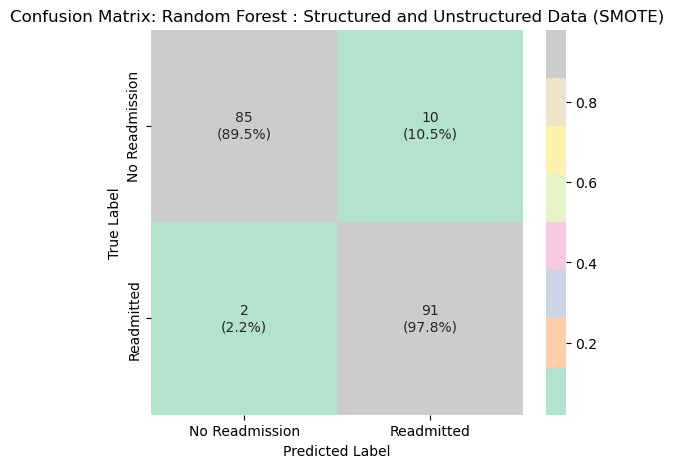


Classification Report for Random Forest : Structured and Unstructured Data (SMOTE):
              precision    recall  f1-score   support

           0       0.98      0.89      0.93        95
           1       0.90      0.98      0.94        93

    accuracy                           0.94       188
   macro avg       0.94      0.94      0.94       188
weighted avg       0.94      0.94      0.94       188



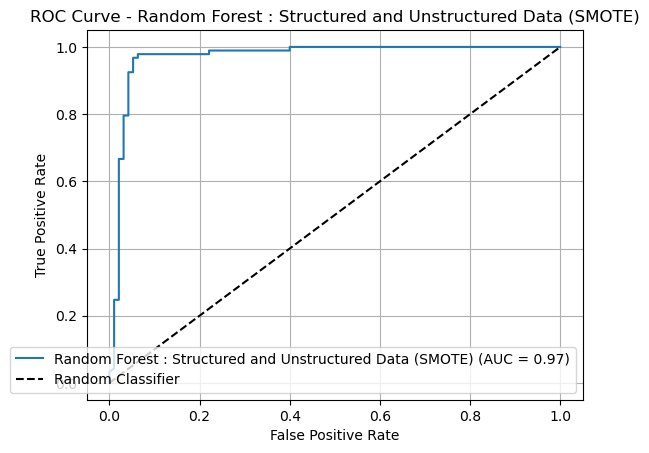

Random Forest : Structured and Unstructured Data (SMOTE) AUC-ROC Score: 0.9698


0.9698358800226372

In [22]:
# Train the Model 
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

#Custom Confusion Matrix
plot_confusion_matrix_with_labels(
    model=rf_model,
    X_test=X_test,
    y_test=y_test,
    class_names=["No Readmission", "Readmitted"],
    model_name="Random Forest : Structured and Unstructured Data (SMOTE)",
    cmap="Pastel2"
)

#ROC Curve
plot_roc_curve(
    model=rf_model,
    X_test=X_test,
    y_test=y_test,
    model_name="Random Forest : Structured and Unstructured Data (SMOTE)"
)


## XGBoost Structed and Unstructed Data after SMOTE

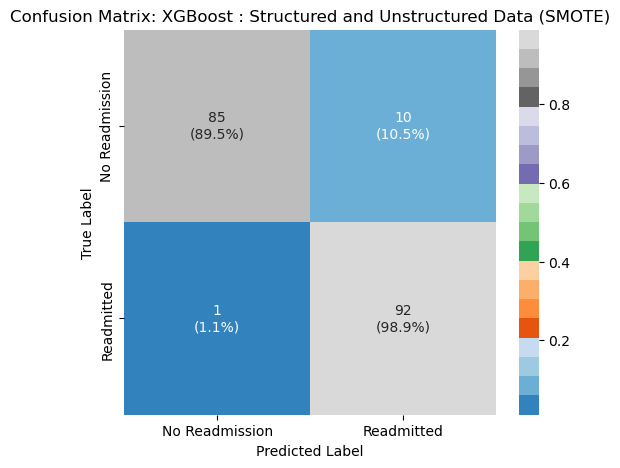


Classification Report for XGBoost : Structured and Unstructured Data (SMOTE):
              precision    recall  f1-score   support

           0       0.99      0.89      0.94        95
           1       0.90      0.99      0.94        93

    accuracy                           0.94       188
   macro avg       0.95      0.94      0.94       188
weighted avg       0.95      0.94      0.94       188



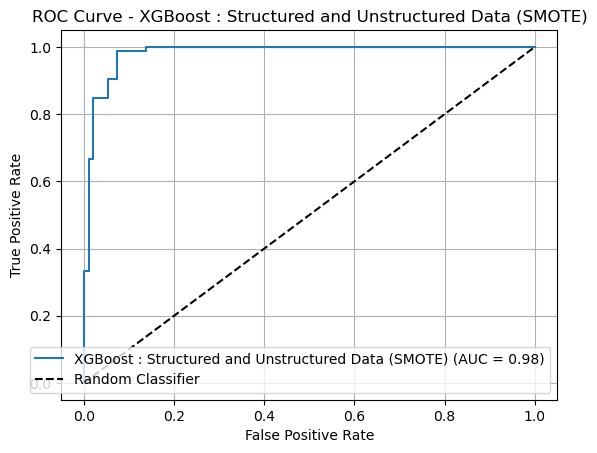

XGBoost : Structured and Unstructured Data (SMOTE) AUC-ROC Score: 0.9820


0.9820033955857386

In [23]:
# Already resampled using SMOTE
X_resampled, y_resampled = smote.fit_resample(X, y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

#Initialize and Train XGBoost Classifier
xgb_model = XGBClassifier(
    n_estimators=100,      # Number of trees in the ensemble
    max_depth=5,           # Maximum depth of each tree
    learning_rate=0.1,     # Coontribution of each tree
    eval_metric='logloss', # Loss function used to evaluate model performance
    random_state=42        # Ensures reproducibility
)

# Fit the XGBoost model to the balanced training data
xgb_model.fit(X_train, y_train)

# Confusion Matrix
plot_confusion_matrix_with_labels(
    model=xgb_model,
    X_test=X_test,
    y_test=y_test,
    class_names=["No Readmission", "Readmitted"],
    model_name="XGBoost : Structured and Unstructured Data (SMOTE)",
    cmap="tab20c"
)

# ROC Curve
plot_roc_curve(
    model=xgb_model,
    X_test=X_test,
    y_test=y_test,
    model_name="XGBoost : Structured and Unstructured Data (SMOTE)"
)



## Tuned XGBoost: Structed and Unstructed Data after SMOTE

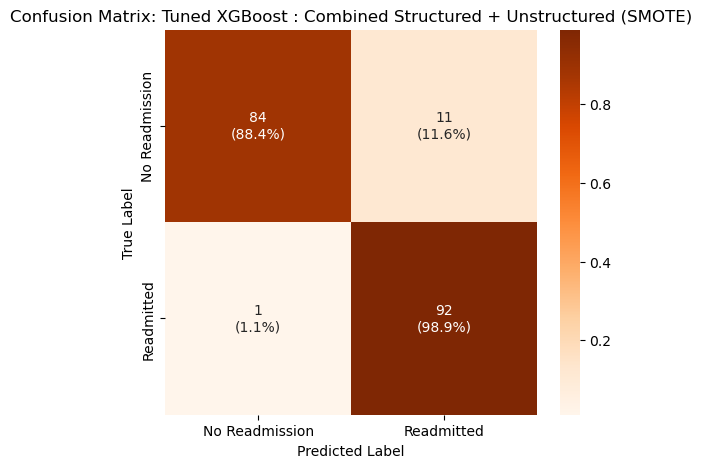


Classification Report for Tuned XGBoost : Combined Structured + Unstructured (SMOTE):
              precision    recall  f1-score   support

           0       0.99      0.88      0.93        95
           1       0.89      0.99      0.94        93

    accuracy                           0.94       188
   macro avg       0.94      0.94      0.94       188
weighted avg       0.94      0.94      0.94       188



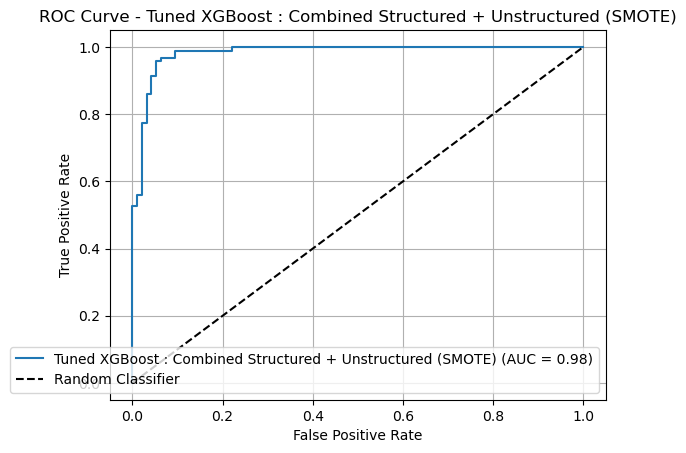

Tuned XGBoost : Combined Structured + Unstructured (SMOTE) AUC-ROC Score: 0.9828


0.9827956989247312

In [24]:
# Tuned XGBoost Model
xgb_tuned = XGBClassifier(
    n_estimators=200,         # Number of boosting rounds
    max_depth=4,              # Slightly shallower trees to prevent overfitting
    learning_rate=0.05,       # Smaller step size for more gradual learning
    subsample=0.8,            # Use 80% of data rows per tree (adds randomness for regularization)
    colsample_bytree=0.8,     # Use 80% of features per tree (also helps prevent overfitting)
    eval_metric='logloss',    # Evaluation metric for binary classification
    random_state=42           # Ensures reproducibility
)

# Train the tuned model using the SMOTE-balanced training data
xgb_tuned.fit(X_train, y_train)

#Confusion Matrix
plot_confusion_matrix_with_labels(
    model=xgb_tuned,
    X_test=X_test,
    y_test=y_test,
    class_names=["No Readmission", "Readmitted"],
    model_name="Tuned XGBoost : Combined Structured + Unstructured (SMOTE)",
    cmap="Oranges"
)

#ROC
plot_roc_curve(
    model=xgb_tuned,
    X_test=X_test,
    y_test=y_test,
    model_name="Tuned XGBoost : Combined Structured + Unstructured (SMOTE)"
)


## Narrowed XGBoost: Structed and Unstructed Data after SMOTE

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Narrowed Parameters: {'subsample': 0.8, 'n_estimators': 150, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.8}


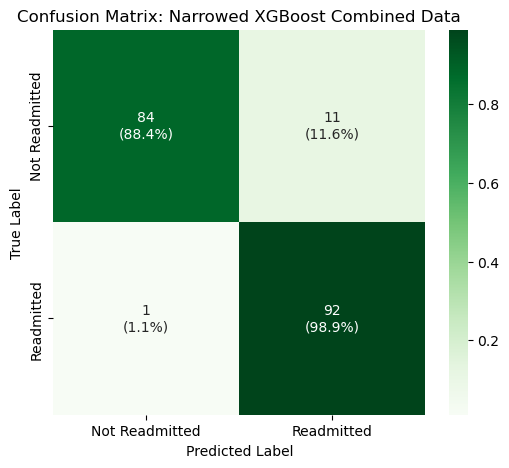


Classification Report for Narrowed XGBoost Combined Data:
              precision    recall  f1-score   support

           0       0.99      0.88      0.93        95
           1       0.89      0.99      0.94        93

    accuracy                           0.94       188
   macro avg       0.94      0.94      0.94       188
weighted avg       0.94      0.94      0.94       188



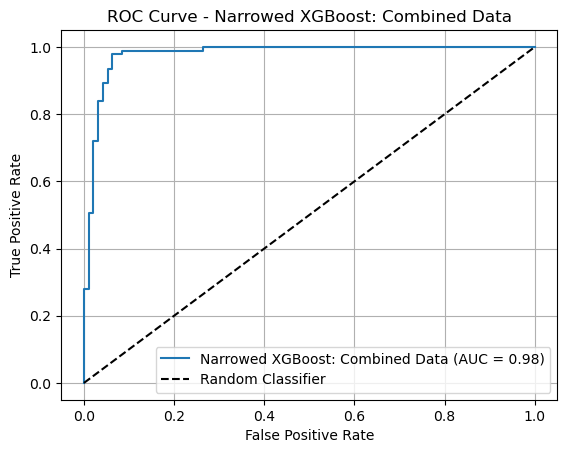

Narrowed XGBoost: Combined Data AUC-ROC Score: 0.9784


0.9783814374646294

In [25]:
#Resplit SMOTE-balanced Data for Tuning

# Create a train-test split from SMOTE
X_train_resampled, X_test, y_train_resampled, y_test = train_test_split(
    X_resampled,            # Features from SMOTE
    y_resampled,            # Balanced target labels
    test_size=0.2,          # 20% test set
    random_state=42         # Ensures reproducibility
)

# Parameter options the tuner will search through
param_dist_narrow = {
    'n_estimators': [150, 200, 250],     # Number of boosting rounds
    'learning_rate': [0.05, 0.1],        # Learning rate (step size shrinkage)
    'max_depth': [3, 4, 5],              # Tree depth
    'subsample': [0.8, 1.0],             # Percentage of rows sampled per tree
    'colsample_bytree': [0.8, 1.0],      # Percentage of features sampled per tree
    'gamma': [0, 0.1]                    # Minimum loss reduction to split a node
}
#Base XGBoost Model
xgb_clf_narrow = XGBClassifier(
    eval_metric='logloss',         # Binary classification loss
    random_state=42
)

#Run Randomized Search (High Recall Focus)
random_search_narrow = RandomizedSearchCV(
    estimator=xgb_clf_narrow,          # Model to tune
    param_distributions=param_dist_narrow,  # Parameter grid
    scoring='recall',                  # Optimize for recall (catching readmissions)
    n_iter=20,                         # Number of combinations to try
    cv=3,                              # 3-fold cross-validation
    verbose=2,                         # Print progress
    random_state=42,                   # Reproducibility
    n_jobs=-1                          # Use all available cores
)

# Perform the tuning
random_search_narrow.fit(X_train_resampled, y_train_resampled)

# Get the best tuned model from the randomized search
best_xgb_narrow = random_search_narrow.best_estimator_

# Print the best combination of hyperparameters found
print("Best Narrowed Parameters:", random_search_narrow.best_params_)

# Predictions on Test Set 
# Predict class labels
y_pred_xgb_narrow = best_xgb_narrow.predict(X_test)

# Predict probabilities for ROC curve
y_prob_xgb_narrow = best_xgb_narrow.predict_proba(X_test)[:, 1]


#Confusion Matrix
plot_confusion_matrix_with_labels(
    best_xgb_narrow, X_test, y_test,
    class_names=["Not Readmitted", "Readmitted"],
    model_name="Narrowed XGBoost Combined Data",
    cmap="Greens"
)

#ROC
plot_roc_curve(
    best_xgb_narrow, X_test, y_test,
    model_name="Narrowed XGBoost: Combined Data"
)